# StyleGAN

Most generators stir `z` into every layer at the same time. StyleGAN split it apart: first map `z` to an intermediate `w`, then inject `w` at every resolution level through AdaIN.

## Problem definition

A DCGAN maps `z` to an image through a stack of transposed convolutions. The problem: `z` controls everything -- pose, lighting, identity, background -- entangled together. Move along one axis of z, all four change. You cannot ask the model "same person, different pose" because the repersentation does not factor that way.

Step feeding `z` directly into conv layers. Feed a constant `4x4x512` tensor as the network input. Learn an 8-layer MLP that maps `z<Z --> w < W`. Inject `w` at every resolution via adaptive instance normalization (ADaIN): normalize each conv feature map, then scale and shift by affine projections of `w`. Add per-layer noise for stochastic detail.

The result: `W` has roughly orthogonal axes for "high-level style" (pos, identify) vs "fine style" (lighting, color). You can swap styles between two images by using image A'w `w` for low-resolution levels and image B's `w` for the high. This unlocked editing, cross-domain stylization, and the entire `StyleGAN-inversion` line of search.

## Basic Concept

StyleGAN: mapping network + AdaIn + per-layer noise

### Mapping network

`f: Z --> W`, an 8 layer MLP. `Z = N(0, I)^512`. `W` is not forces to be Gaussian -- it learns a data-accepted shape.

### Synthesis network

Starts from a learned constant `4x4x512`. Each resolution block: `upsample --> conv --> AdaIN(w_i) --> noise --> conv --> AdaIn(w_i) --> noise`. Resolution double: 4, 8, 16 ... 1025.

### AdaIN

```
AdaIn(x, y) = y_scale * (x - mean(x)) / std(x) + y_bias
```

Where `y_scale` and `y_bias` come from affine probejctions of `w`. Normalized per feature map, the restyle. "Style" here is the first-and second-order statistic of the feature map.

### Per-layer noise

Singla-channel Gaussian noise added to each feature map, scaled by a learned per-channel factor. Controls stochastic defail without affecting glbal structure.

### Truncation trick

At inference, sample `z`, compute `w = mapping(z)`, then `w' = w_hat + phi*(w - w')` where `w_hat` is the mean `w` over many samples. `phi < 1` trades diversity for quality. Usally 0.7.

# Build your Own

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(3)

Z_DIM, W_DIM, HIDDEN, DEPTH = 8, 8, 6, 4


class AdaIN(nn.Module):
    def __init__(self, w_dim, n_features):
        super().__init__()
        # 每个特征维独立的 scale / bias，否则后层会整段覆盖前层 style
        self.style = nn.Linear(w_dim, 2 * n_features)

    def forward(self, x, w):
        m = x.mean(dim=-1, keepdim=True)
        s = x.std(dim=-1, keepdim=True) + 1e-8
        scale, bias = self.style(w).chunk(2, dim=-1)
        return scale * (x - m) / s + bias


class MappingNetwork(nn.Module):
    def __init__(self, z_dim, w_dim, depth):
        super().__init__()
        layers = []
        dims = [z_dim] + [w_dim] * depth
        for i in range(depth):
            layers += [nn.Linear(dims[i], dims[i + 1]), nn.LeakyReLU(0.2)]
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)


class SynthBlock(nn.Module):
    def __init__(self, hidden, w_dim):
        super().__init__()
        self.conv = nn.Linear(hidden, hidden)
        self.adain = AdaIN(w_dim, hidden)
        # demo 用：非零噪声幅度，否则 noise_sigma>0 也看不到变化
        self.noise_weight = nn.Parameter(torch.ones(1))

    def forward(self, x, w, noise_sigma=0.0, adain_on=True):
        x = F.leaky_relu(self.conv(x), 0.2)
        if adain_on:
            x = self.adain(x, w)
        if noise_sigma > 0:
            x = x + self.noise_weight * noise_sigma * torch.randn_like(x)
        return x


class SynthesisNetwork(nn.Module):
    """Tiny synthesis net: learned constant + 3 blocks (StyleGAN idea, 1D toy)."""

    def __init__(self, hidden, w_dim, n_layers=3):
        super().__init__()
        self.const = nn.Parameter(torch.randn(hidden) * 0.3)
        self.blocks = nn.ModuleList(SynthBlock(hidden, w_dim) for _ in range(n_layers))

    def forward(self, w, noise_sigma=0.0, adain_on=True, w_per_block=None):
        batch = w.shape[0] if w_per_block is None else w_per_block[0].shape[0]
        x = self.const.unsqueeze(0).expand(batch, -1)
        for i, block in enumerate(self.blocks):
            wi = w_per_block[i] if w_per_block is not None else w
            x = block(x, wi, noise_sigma, adain_on)
        return x


def _spread_linear_(m, std=0.5):
    """默认 Linear 初始化过小，多层 mapping 会把 W 压扁，truncation 看不见。"""
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0.0, std)
        nn.init.zeros_(m.bias)


mapping = MappingNetwork(Z_DIM, W_DIM, DEPTH)
mapping.apply(_spread_linear_)
synth = SynthesisNetwork(HIDDEN, W_DIM)

print("=== compare: style inputs via AdaIN vs no AdaIN ===")
print("metric = across-sample std (different z → how much output moves)")

for adain_on in [True, False]:
    outs = []
    for _ in range(5):
        z = torch.randn(1, Z_DIM)
        w = mapping(z)
        outs.append(synth(w, adain_on=adain_on))
    stacked = torch.cat(outs)  # (5, HIDDEN)
    across = stacked.std(dim=0).mean().item()
    label = "with AdaIN" if adain_on else "no AdaIN  "
    print(f"  {label}: across-sample std {across:.3f}")

print()
print("=== truncation trick: w' = w_bar + psi * (w - w_bar) ===")
with torch.no_grad():
    w_bar = mapping(torch.randn(200, Z_DIM)).mean(dim=0)
    w_test = mapping(torch.randn(1, Z_DIM)).squeeze(0)
    h_mean = synth(w_bar.unsqueeze(0)).squeeze(0)

for psi in [0.0, 0.5, 0.7, 1.0]:
    w_psi = w_bar + psi * (w_test - w_bar)
    h = synth(w_psi.unsqueeze(0)).squeeze(0)
    dist = (h - h_mean).norm().item()
    print(
        f"  psi={psi:.1f}: ||out - out_mean||={dist:.3f}  "
        f"output={[f'{v:+.2f}' for v in h.tolist()]}"
    )

print()
print("=== per-layer noise injection (pose fixed, stochastic detail changes) ===")
with torch.no_grad():
    w_fixed = mapping(torch.randn(1, Z_DIM))

for seed in range(3):
    torch.manual_seed(seed)
    h = synth(w_fixed, noise_sigma=0.3).squeeze(0)
    print(f"  seed {seed}: {[f'{v:+.2f}' for v in h.tolist()]}")

print()
print("notice: with the same w, outputs vary with noise seed.")
print("         that is the stochastic-detail vs global-style split.")


=== compare: style inputs via AdaIN vs no AdaIN ===
sample 5 random z, look at std of output under each mode
  with AdaIN: mean +0.386  std 0.090
  no AdaIN  : mean +0.079  std 0.125

=== truncation trick: sample many w, take mean, interpolate ===
  psi=0.0: output = ['+0.32', '+0.32', '+0.32', '+0.33', '+0.56', '+0.45']
  psi=0.5: output = ['+0.32', '+0.32', '+0.32', '+0.33', '+0.56', '+0.45']
  psi=0.7: output = ['+0.32', '+0.31', '+0.32', '+0.33', '+0.57', '+0.45']
  psi=1.0: output = ['+0.32', '+0.31', '+0.32', '+0.32', '+0.57', '+0.44']

=== per-layer noise injection (pose fixed, stochastic detail changes) ===
  seed 0: ['+0.31', '+0.30', '+0.31', '+0.31', '+0.57', '+0.45']
  seed 1: ['+0.31', '+0.30', '+0.31', '+0.31', '+0.57', '+0.45']
  seed 2: ['+0.31', '+0.30', '+0.31', '+0.31', '+0.57', '+0.45']

notice: with the same w, outputs vary slightly with noise seed.
         that is the stochastic-detail vs global-style split.


## StyleGAN vs 原始 GAN：Style Mixing

原始 GAN 把 `z` **只在入口注入一次**。想混合两个样本，最自然的操作是 **z 插值** `0.5(z_A+z_B)`——粗、细属性会一起被平均，无法「只要 A 的姿势 + B 的光照」。

StyleGAN 在**每一层**注入 `w`。推理时可以：
- 前几层用 `w_A`（粗粒度：输出前 3 维）
- 后几层用 `w_B`（细粒度：输出后 3 维）

得到 **A 的粗 + B 的细**，而无需知道 latent 里哪一维对应哪个属性。

本实验取：
- **A**：coarse=−，fine=−
- **B**：coarse=+，fine=+
- **混合目标**：A 的 coarse（−）+ B 的 fine（+）→ 既不是 A 也不是 B

> 注意：若给 Classic 显式 `concat(z_c_A, z_f_B)`，它也能拼对——那是因为你已经按通道拆好了标签。真实场景里 latent 是纠缠的，StyleGAN 的按层混合才是架构优势。

step 1000: style 0.0000  classic 0.0000
step 2000: style 0.0000  classic 0.0000
step 3000: style 0.0000  classic 0.0000
step 4000: style 0.0000  classic 0.0000
============Style mixing: A's coarse + B's fine=============
target: [-1.0, -1.0, -1.0, 1.0, 1.0, 1.0]
StyleGAN A              first3=-1.00  last3=-1.00  |err|=1.00
StyleGAN B              first3=-1.00  last3=+1.00  |err|=0.00
StyleGAN layer-mix      first3=-1.00  last3=+1.00  |err|=0.00
Classic z-interp        first3=-1.04  last3=-0.20  |err|=0.62


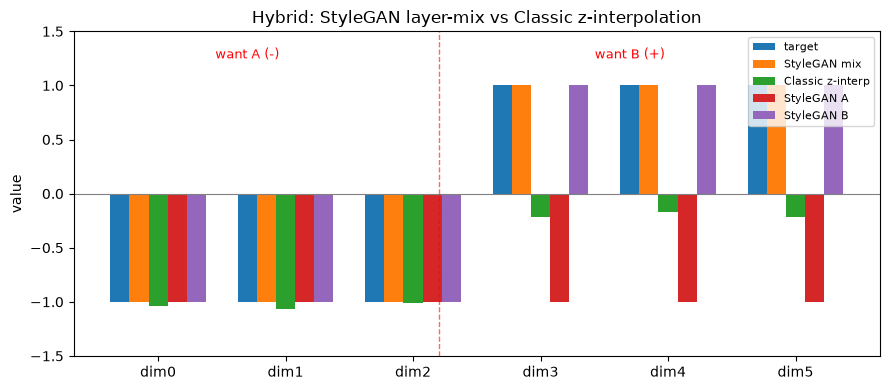

In [9]:
import sys
from pathlib import Path

sys.path.append(str(Path("../../00_Common").resolve()))
from user_tools import SectionPrinter

import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)

Z_HALF = 4  # 2 noise + 2 one-hot
STEPS = 4000
BATCH = 128


def make_z(noise, label):
    return torch.cat([noise, F.one_hot(label, 2).float()], dim=1)


def make_target(coarse, fine):
    c = torch.where(coarse.unsqueeze(1) == 0, -1.0, 1.0).expand(-1, 3)
    f = torch.where(fine.unsqueeze(1) == 0, -1.0, 1.0).expand(-1, 3)
    return torch.cat([c, f], dim=1)


class ClassicGenerator(nn.Module):
    """原始 GAN：单一 z 只在入口注入，没有按层 style 接口。"""

    def __init__(self, z_dim, hidden, out_dim=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, z):
        return self.net(z)


style_mapping = MappingNetwork(Z_HALF, W_DIM, DEPTH)
style_synth = SynthesisNetwork(HIDDEN, W_DIM)
classic = ClassicGenerator(Z_HALF * 2, HIDDEN)

opt_style = torch.optim.Adam(
    list(style_mapping.parameters()) + list(style_synth.parameters()), lr=2e-3
)
opt_classic = torch.optim.Adam(classic.parameters(), lr=2e-3)
loss_fn = nn.MSELoss()

for step in range(1, STEPS + 1):
    coarse = torch.randint(0, 2, (BATCH,))
    fine = torch.randint(0, 2, (BATCH,))
    z_c = make_z(torch.randn(BATCH, Z_HALF - 2), coarse)
    z_f = make_z(torch.randn(BATCH, Z_HALF - 2), fine)
    target = make_target(coarse, fine)

    w_c, w_f = style_mapping(z_c), style_mapping(z_f)
    out_style = style_synth(w_c, w_per_block=[w_c, w_c, w_f])
    opt_style.zero_grad()
    loss_fn(out_style, target).backward()
    opt_style.step()

    out_classic = classic(torch.cat([z_c, z_f], dim=1))
    opt_classic.zero_grad()
    loss_fn(out_classic, target).backward()
    opt_classic.step()

    if step % 1000 == 0:
        print(
            f"step {step}: style {loss_fn(out_style, target).item():.4f}  "
            f"classic {loss_fn(out_classic, target).item():.4f}"
        )


style_mapping.eval()
style_synth.eval()
classic.eval()

with torch.no_grad():
    # A: coarse=-, fine=-   B: coarse=+, fine=+
    # hybrid: A's coarse (-) + B's fine (+)  → 既不是 A 也不是 B
    z_c_a = make_z(torch.randn(1, Z_HALF - 2), torch.tensor([0]))
    z_f_a = make_z(torch.randn(1, Z_HALF - 2), torch.tensor([0]))
    z_c_b = make_z(torch.randn(1, Z_HALF - 2), torch.tensor([1]))
    z_f_b = make_z(torch.randn(1, Z_HALF - 2), torch.tensor([1]))

    w_c_a, w_f_a = style_mapping(z_c_a), style_mapping(z_f_a)
    w_c_b, w_f_b = style_mapping(z_c_b), style_mapping(z_f_b)

    out_a = style_synth(w_c_a, w_per_block=[w_c_a, w_c_a, w_f_a]).squeeze(0)
    out_b = style_synth(w_c_b, w_per_block=[w_c_b, w_c_b, w_f_b]).squeeze(0)

    # StyleGAN native op: swap styles per layer
    out_style_mix = style_synth(w_c_a, w_per_block=[w_c_a, w_c_a, w_f_b]).squeeze(0)

    z_a = torch.cat([z_c_a, z_f_a], dim=1)
    z_b = torch.cat([z_c_b, z_f_b], dim=1)
    # Classic native op: only z-space interpolation (doesn't know which dims are coarse/fine)
    out_classic_interp = classic(0.5 * (z_a + z_b)).squeeze(0)

    hybrid_target = torch.tensor([-1.0, -1.0, -1.0, 1.0, 1.0, 1.0])


def summarize(name, vec):
    err = (vec - hybrid_target).abs().mean().item()
    print(
        f"{name:22s}  first3={vec[:3].mean():+.2f}  last3={vec[3:].mean():+.2f}  "
        f"|err|={err:.2f}"
    )


with SectionPrinter("Style mixing: A's coarse + B's fine"):
    print("target:", hybrid_target.tolist())
    summarize("StyleGAN A", out_a)
    summarize("StyleGAN B", out_b)
    summarize("StyleGAN layer-mix", out_style_mix)
    summarize("Classic z-interp", out_classic_interp)

    names = ["target", "StyleGAN mix", "Classic z-interp", "StyleGAN A", "StyleGAN B"]
    vecs = [
        hybrid_target.numpy(),
        out_style_mix.numpy(),
        out_classic_interp.numpy(),
        out_a.numpy(),
        out_b.numpy(),
    ]

    x = np.arange(6)
    width = 0.15
    fig, ax = plt.subplots(figsize=(9, 4))
    for i, (name, vec) in enumerate(zip(names, vecs)):
        ax.bar(x + i * width, vec, width, label=name)
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(2.5, color="red", ls="--", lw=1, alpha=0.6)
    ax.text(1.0, 1.25, "want A (-)", ha="center", color="red", fontsize=9)
    ax.text(4.0, 1.25, "want B (+)", ha="center", color="red", fontsize=9)
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels([f"dim{i}" for i in range(6)])
    ax.set_ylim(-1.5, 1.5)
    ax.set_ylabel("value")
    ax.set_title("Hybrid: StyleGAN layer-mix vs Classic z-interpolation")
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()
